## Core microbiome thresholds / Figure 2

All files on farm in `/home/ctbrown/scratch3/2025-workflow-core99/`

In [1]:
# base checkout of workflow directory is here:
BASE='/home/ctbrown/scratch3/2025-workflow-core99/'

# parquet files from 'sourmash gather' against 3,216 metagenomes
BASE_OUTPUTS=BASE+'/outputs.core2'

# where to place figures
FIG_OUT=BASE+'/outputs.figures/'

In [2]:
import polars as pl
import glob
import matplotlib.pyplot as plt

In [3]:
filenames = glob.glob(BASE_OUTPUTS + '/*.parquet')

dflist = []

all_df = (pl.scan_parquet(filenames)
          .select(["match_name", "containment", "query_name", "intersect_hashes", "scaled"])).collect()


In [4]:
assert all_df["query_name"].n_unique() == 3216
print(f"loaded {all_df['query_name'].n_unique()} gathers.")

loaded 3216 gathers.


In [5]:
all_df = all_df.with_columns((pl.col("intersect_hashes") * pl.col("scaled")).alias("intersect_bp"))

In [6]:
all_df = all_df.filter(pl.col("intersect_bp") >= 20_000)

In [7]:
all_df

match_name,containment,query_name,intersect_hashes,scaled,intersect_bp
str,f64,str,i64,i64,i64
"""GCA_002472535 s__Prevotella sp…",0.001495,"""SRR11723728""",1879,1000,1879000
"""GCA_902761335 s__UBA2810 sp900…",0.001458,"""SRR11723728""",1832,1000,1832000
"""GCF_012843515 s__Megasphaera e…",0.001418,"""SRR11723728""",1782,1000,1782000
"""GCA_902759695 s__Prevotella sp…",0.001323,"""SRR11723728""",1663,1000,1663000
"""GCA_900315415 s__UBA629 sp9003…",0.001276,"""SRR11723728""",1603,1000,1603000
…,…,…,…,…,…
"""GCA_015058525 s__Clostridium b…",0.000029,"""SRR8960611""",20,1000,20000
"""GCA_034117365 s__Alloenteromon…",0.000029,"""SRR8960611""",20,1000,20000
"""GCF_036551285 s__Hominimerdico…",0.000029,"""SRR8960611""",20,1000,20000


In [8]:
meta_df = pl.read_csv(BASE + '/inputs.metadata/SRA_meta.3216.csv')
meta_df = meta_df.select(['acc', 'mbases'])
meta_df

acc,mbases
str,i64
"""SRR8960471""",4274
"""ERR1135330""",6819
"""SRR8960499""",5236
"""SRR8960204""",16136
"""ERR1135371""",7026
…,…
"""SRR11183408""",1032
"""SRR8960862""",7212
"""SRR8960937""",5460


In [9]:
def filter_combined_df_by_threshold(combined_df, frac, threshold_bp):
    min_mbases = 1000
    sub_df = combined_df.filter(((pl.col("mbases") >= min_mbases) & 
                                (pl.col("intersect_bp") >= threshold_bp)))

    total = sub_df["query_name"].n_unique()
    cutoff = int(frac * total + 1)

    group_df = sub_df.group_by('match_name') \
            .agg(pl.len()) \
            .filter(pl.col("len") >= cutoff)
    return (cutoff, total, group_df)

In [10]:
combo_df = all_df.join(meta_df, left_on='query_name', right_on='acc', how='inner')

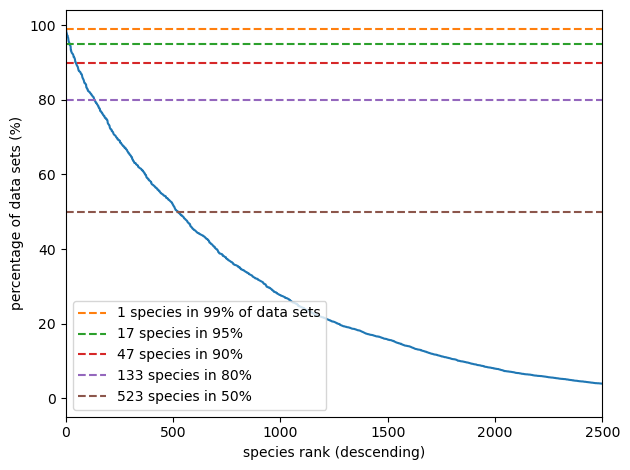

In [11]:
frac = 0
min_mbases = 1000
cutoff, total, group_df = filter_combined_df_by_threshold(combo_df, frac, 10_000)
#print(f"at {min_mbases/1000}gb, there are {len(group_df)} species present across at least {frac*100:.1f}% ({cutoff}) of the {total} datasets")

group_df = group_df.sort("len", descending=True).with_columns(
    (pl.col("len") / total).alias("frequency")
).with_row_index(name="rank")

len99 = len(group_df.filter(pl.col("frequency") >= 0.99))
len95 = len(group_df.filter(pl.col("frequency") >= 0.95))
len90 = len(group_df.filter(pl.col("frequency") >= 0.90))
len80 = len(group_df.filter(pl.col("frequency") >= 0.80))
len50 = len(group_df.filter(pl.col("frequency") >= 0.50))


plt.plot(group_df["rank"], group_df["frequency"]*100)
plt.plot([0, len(group_df)], [99, 99], '--', label=f'{len99} species in 99% of data sets')
plt.plot([0, len(group_df)], [95, 95], '--', label=f'{len95} species in 95%')
plt.plot([0, len(group_df)], [90, 90], '--', label=f'{len90} species in 90%')
plt.plot([0, len(group_df)], [80, 80], '--', label=f'{len80} species in 80%')
plt.plot([0, len(group_df)], [50, 50], '--', label=f'{len50} species in 50%')

#plt.title("num core species at various thresholds in >= 1GB datasets")
plt.xlabel("species rank (descending)")
plt.ylabel("percentage of data sets (%)")
plt.legend(loc='lower left')
plt.xlim(0, 2500)
plt.tight_layout()
plt.savefig(FIG_OUT+'figure2-core-microbiome-curve.png')

## Figure 2: The size of the core microbiome depends critically on the frequency cutoff chosen.
Species ordered by frequency with which their pangenomes were detected across of 3,216 pig gut shotgun metagenome data sets. The minimum detection threshold was set at 10kb. The Y axis is the percentage of total data sets in which each species was found. The X axis is species number ordered by frequency rank, with highest frequency organism (E. coli, at 100%) starting at position 0.

In [12]:
len(group_df.filter(pl.col("frequency") >= 0.50))

523

In [13]:
sub_df = group_df.filter((pl.col("frequency") >= 0.95))
#matches = sub_df.sample(11, seed=42)

with pl.Config(tbl_rows=-1):
    print(sub_df)

shape: (17, 4)
┌──────┬─────────────────────────────────┬──────┬───────────┐
│ rank ┆ match_name                      ┆ len  ┆ frequency │
│ ---  ┆ ---                             ┆ ---  ┆ ---       │
│ u32  ┆ str                             ┆ u32  ┆ f64       │
╞══════╪═════════════════════════════════╪══════╪═══════════╡
│ 0    ┆ GCA_022772045 s__Sodaliphilus … ┆ 3188 ┆ 0.991294  │
│ 1    ┆ GCF_023523445 s__Lactobacillus… ┆ 3183 ┆ 0.989739  │
│ 2    ┆ GCA_958345775 s__Mogibacterium… ┆ 3155 ┆ 0.981032  │
│ 3    ┆ GCA_945928745 s__UBA2868 sp004… ┆ 3152 ┆ 0.9801    │
│ 4    ┆ GCA_946410115 s__Cryptobactero… ┆ 3147 ┆ 0.978545  │
│ 5    ┆ GCA_945876855 s__JAFBIX01 sp02… ┆ 3136 ┆ 0.975124  │
│ 6    ┆ GCA_945864645 s__Fimisoma sp00… ┆ 3132 ┆ 0.973881  │
│ 7    ┆ GCF_008634965 s__Escherichia c… ┆ 3124 ┆ 0.971393  │
│ 8    ┆ GCF_034115845 s__Floccifex por… ┆ 3124 ┆ 0.971393  │
│ 9    ┆ GCA_902756905 s__Prevotella sp… ┆ 3115 ┆ 0.968595  │
│ 10   ┆ GCA_028721505 s__Cryptobactero… ┆ 3111 ┆ 0.967

In [14]:
sub_df = group_df.filter((pl.col("frequency") >= 0.95))
core_matches = set([ " ".join(x.split(' ')[1:3]) for x in sub_df['match_name'] ])
print(core_matches)

{'s__Cryptobacteroides sp034089285', 's__Bariatricus sp004560705', 's__Mogibacterium_A kristiansenii', 's__Sodaliphilus sp004557565', 's__Escherichia coli', 's__Prevotella sp000434975', 's__Floccifex porci', 's__Ornithospirochaeta sp022785155', 's__Cryptobacteroides sp000432655', 's__Colivicinus sp002299675', 's__Fimisoma sp002320005', 's__Prevotella sp002251295', 's__Cryptobacteroides sp900546925', 's__Cryptobacteroides sp000434935', 's__UBA2868 sp004552595', 's__JAFBIX01 sp021531895', 's__Lactobacillus amylovorus'}


In [15]:
names = set([ x.strip() for x in open('../inputs.mapping/names.list') ])
print(names)

FileNotFoundError: [Errno 2] No such file or directory: '../inputs.mapping/names.list'

In [ ]:
# shared => old
core_matches.intersection(names)

In [ ]:
# all new ones
core_matches - names

In [ ]:
# missing old ones
names - core_matches